## `jitr` quickstart example

We will 
- compile a solver for a particular reaction and kinematics
-  define a parametric potential and generate samples of the interaction parameters
-  propagate parameter samples through our compiled solver to generate predictive distributions of reaction observables

To illustrate, we will use the example of $\alpha$ elastic scattering on $^{48}$Ca at 29 MeV, comparing to experimental data from [EXFOR](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=14669&subID=150567004&plus=1).

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from tqdm import tqdm

from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere as coulomb,
)
from jitr.optical_potentials.potential_forms import (
    woods_saxon_safe as ws,
)
from jitr.reactions.reaction import Reaction
from jitr.rmatrix import Solver as SolverKernel
from jitr.utils import utils
from jitr.xs import elastic

# define reaction system
alpha = (4, 2)
Ca48 = (48, 20)
reaction = Reaction(target=Ca48, projectile=alpha, process="El")

# calculate kinematics for a given lab energy
energy_lab = 28.2
kinematics = reaction.kinematics(energy_lab)

# set the channel radius, number of nodes, and number of partial waves
interaction_range_fm = 1.2 * (48 ** (1 / 3) + 4 ** (1 / 3)) + 2
channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
    interaction_range_fm, kinematics.k
)
channel_radius = channel_radius_dimensionless / kinematics.k
N = utils.suggested_basis_size(channel_radius_dimensionless)
lmax = 180

# build a solver for the system and reaction of interest
print(f"Compiling solver for {reaction} at {energy_lab} MeV")
print(f" - channel radius {channel_radius:1.2f} fm")
print(f" - {N} nodes")
print(f" - {lmax} partial waves")

solver = elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius,
    solver=SolverKernel(N),
    lmax=lmax,
    angles=np.linspace(0.1, np.pi, 180),
)
rgrid = solver.radial_grid()
# jit warmup
_ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))
print("Done!")

Compiling solver for 48-Ca(alpha,el) at 28.2 MeV
 - channel radius 11.19 fm
 - 40 nodes
 - 180 partial waves
Done!


In [2]:
# define interaction
def U_central(r, Vv, Wv, Rv, av):
    fr = ws(r, Rv, av)
    return -(Vv * fr + 1j * Wv * fr)


def V_Coulomb(r, Zz, RC):
    return coulomb(r, Zz, RC)


# define parameter distribution and draw samples
# just
param_means = np.array([185, 20, 1.0, 0.6, 1.2])
param_std_devs = np.array([6, 2, 0.05, 0.05, 0.01])
num_samples = 1000
param_draws = stats.multivariate_normal(
    mean=param_means, cov=np.diag(param_std_devs) ** 2
).rvs(num_samples)

print(f"Running {num_samples} calculations...")
prediction_samples = np.zeros((num_samples, solver.angles.size))
for i in tqdm(range(param_draws.shape[0])):
    Vv, Wv, rv, av, rC = param_draws[i]
    A_factor = reaction.target.A ** (1 / 3) + reaction.projectile.A ** (1 / 3)
    Zz = reaction.target.Z * reaction.projectile.Z
    xs = solver.xs(
        central_potential=U_central(
            rgrid,
            Vv,
            Wv,
            rv * A_factor,
            av,
        ),
        coulomb_potential=V_Coulomb(rgrid, Zz, rC * A_factor),
    )
    prediction_samples[i, :] = xs.dsdo / solver.rutherford

print("Done!")

Running 1000 calculations...


100%|██████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 168.00it/s]

Done!


We will compare to some experimental data from [EXFOR](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=14669&subID=150567004&plus=1) 

In [3]:
import pandas as pd

df = pd.read_csv("./alpha_ca48_ratio_ruth.txt", names=["angle", "xs"], sep=r"\s+")

### Plot predictive cross section distribution

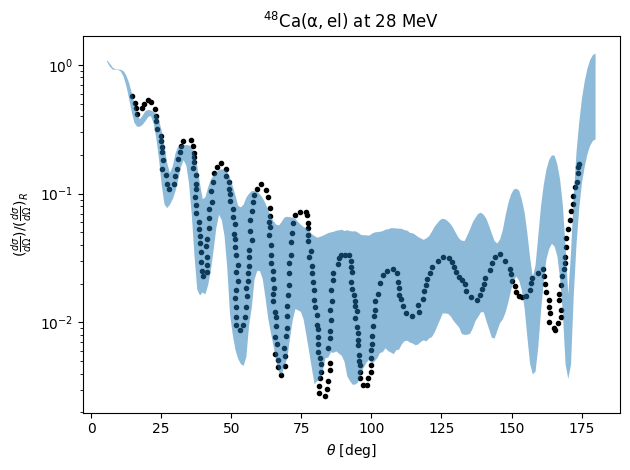

In [4]:
plt.figure()
plt.scatter(df["angle"], df["xs"], color="k", marker=".")

plt.fill_between(
    np.rad2deg(solver.angles),
    *np.percentile(prediction_samples, [16, 84], axis=0),
    alpha=0.5,
)
plt.yscale("log")
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_{R}$")
plt.title(f"${reaction.reaction_latex}$ at {kinematics.Elab:1.0f} MeV")
plt.tight_layout()
plt.show()

This looks like a reasonable prior! The next steps would be to use Bayesian calibration to determine a posterior...